# 02 — Khí hậu ERA5-Land (Copernicus CDS)

Luồng A3+A4 — [PHASE-1-CHECKLIST.md §A3-A4](../../PHASE-1-CHECKLIST.md). Đây là bước **duy nhất** trong Luồng A cần bạn tự làm 1 việc thủ công: đăng ký tài khoản [cds.climate.copernicus.eu](https://cds.climate.copernicus.eu), vào dataset **ERA5-Land monthly averaged data** bấm accept Terms of Use, rồi tạo file `~/.cdsapirc`:
```
url: https://cds.climate.copernicus.eu/api
key: <personal-access-token>
```
Cell dưới tự kiểm tra file này có chưa trước khi chạy gì khác.

In [1]:
import sys
from pathlib import Path

_root = Path.cwd()
if not (_root / "app").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print("project root:", _root)

project root: d:\Cuộc thi\DengueSense\ai-service


In [2]:
from pathlib import Path

cdsapirc = Path.home() / '.cdsapirc'
if not cdsapirc.exists():
    raise FileNotFoundError(
        f'Chưa có {cdsapirc} — đăng ký tài khoản CDS và tạo file này trước '
        '(xem hướng dẫn ở cell markdown phía trên).'
    )
print('Tìm thấy', cdsapirc)

Tìm thấy C:\Users\Nguyen Dao Nam Hai\.cdsapirc


In [3]:
from app.data.ingest_era5 import (
    VN_BBOX,
    build_climate_panel,
    fetch_all_years,
    load_and_convert,
    sanity_check,
)

print('Bbox tải (N, W, S, E):', VN_BBOX)

Bbox tải (N, W, S, E): [23.7, 101.8, 7.0, 118.2]


## Tải theo từng năm

Mỗi request xếp hàng ở CDS, có thể mất vài phút tới vài chục phút tuỳ tải hệ thống — **chạy cell này rồi làm việc khác trong lúc chờ**. `fetch_all_years()` tự bỏ qua năm đã tải, tự retry (3 lần, backoff) nếu 1 request lỗi, và KHÔNG dừng cả loạt nếu 1 năm lỗi hẳn — năm nào lỗi sẽ in ra và trả về trong `failed_years` để biết chạy bù sau. Đổi `YEARS` thành khoảng nhỏ (vd `range(2020, 2021)`) để test nhanh trước.

In [4]:
YEARS = range(1994, 2026)

failed_years = fetch_all_years(YEARS)
print(f"\nXong. {len(failed_years)} năm lỗi hẳn: {failed_years}")

[era5 1/32] 1994: OK
[era5 2/32] 1995: OK
[era5 3/32] 1996: OK
[era5 4/32] 1997: OK
[era5 5/32] 1998: OK
[era5 6/32] 1999: OK
[era5 7/32] 2000: OK
[era5 8/32] 2001: OK
[era5 9/32] 2002: OK
[era5 10/32] 2003: OK
[era5 11/32] 2004: OK
[era5 12/32] 2005: OK
[era5 13/32] 2006: OK
[era5 14/32] 2007: OK
[era5 15/32] 2008: OK
[era5 16/32] 2009: OK
[era5 17/32] 2010: OK
[era5 18/32] 2011: OK
[era5 19/32] 2012: OK
[era5 20/32] 2013: OK
[era5 21/32] 2014: OK
[era5 22/32] 2015: OK
[era5 23/32] 2016: OK
[era5 24/32] 2017: OK
[era5 25/32] 2018: OK
[era5 26/32] 2019: OK
[era5 27/32] 2020: OK
[era5 28/32] 2021: OK
[era5 29/32] 2022: OK
[era5 30/32] 2023: OK
[era5 31/32] 2024: OK
[era5 32/32] 2025: OK

Xong. 0 năm lỗi hẳn: []


## Sanity check đơn vị (1 năm mẫu)

Nhiệt độ VN phải 5-40°C, độ ẩm 30-100%, mưa ≥ 0. Sai khoảng này gần như chắc chắn quên đổi Kelvin hoặc quên nhân số ngày trong tháng cho mưa.

In [5]:
from app.data.ingest_era5 import RAW_DIR

sample_year = max(y for y in YEARS if y not in failed_years)
sample_ds = load_and_convert(RAW_DIR / f'era5_land_monthly_{sample_year}.nc')
sanity_check(sample_ds)

,variable,min,mean,max
0,temp_c,7.229401,23.427790,30.741119
1,precip_mm,0.027043,168.856559,1084.337414
2,humidity_pct,45.761059,77.599663,96.189713


## Zonal stats: raster → (tỉnh, tháng)

v1 = trung bình theo diện tích đơn thuần (`stat='mean'`), không trọng số dân số — xem PHASE-1-CHECKLIST §A4 cho nâng cấp v2.

In [6]:
import matplotlib.pyplot as plt

climate_panel = build_climate_panel(YEARS)
climate_panel.head()

d:\Cuộc thi\DengueSense\ai-service\venv\Lib\site-packages\rasterstats\io.py:437: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


[zonal era5] 1994: OK
[zonal era5] 1995: OK
[zonal era5] 1996: OK
[zonal era5] 1997: OK
[zonal era5] 1998: OK
[zonal era5] 1999: OK
[zonal era5] 2000: OK
[zonal era5] 2001: OK
[zonal era5] 2002: OK
[zonal era5] 2003: OK
[zonal era5] 2004: OK
[zonal era5] 2005: OK
[zonal era5] 2006: OK
[zonal era5] 2007: OK
[zonal era5] 2008: OK
[zonal era5] 2009: OK
[zonal era5] 2010: OK
[zonal era5] 2011: OK
[zonal era5] 2012: OK
[zonal era5] 2013: OK
[zonal era5] 2014: OK
[zonal era5] 2015: OK
[zonal era5] 2016: OK
[zonal era5] 2017: OK
[zonal era5] 2018: OK
[zonal era5] 2019: OK
[zonal era5] 2020: OK
[zonal era5] 2021: OK
[zonal era5] 2022: OK
[zonal era5] 2023: OK
[zonal era5] 2024: OK
[zonal era5] 2025: OK


,province_id,temp_mean,precip_total,humidity_mean,month
0,an_giang,25.946057,9.781486,71.692729,1994-01-01
1,bac_ninh,17.062128,25.167253,73.346132,1994-01-01
2,ca_mau,25.617043,16.808518,75.741575,1994-01-01
3,can_tho,25.370067,8.774281,75.615847,1994-01-01
4,cao_bang,13.655302,45.530970,77.348562,1994-01-01


## Sanity check zonal (1 tỉnh, chuỗi thời gian)

Nhiệt độ trung bình tháng của 1 tỉnh phải có dao động mùa vụ rõ (nóng hơn giữa năm), không phẳng lì (dấu hiệu zonal stat bị lỗi, toàn NaN hoặc toàn 1 giá trị).

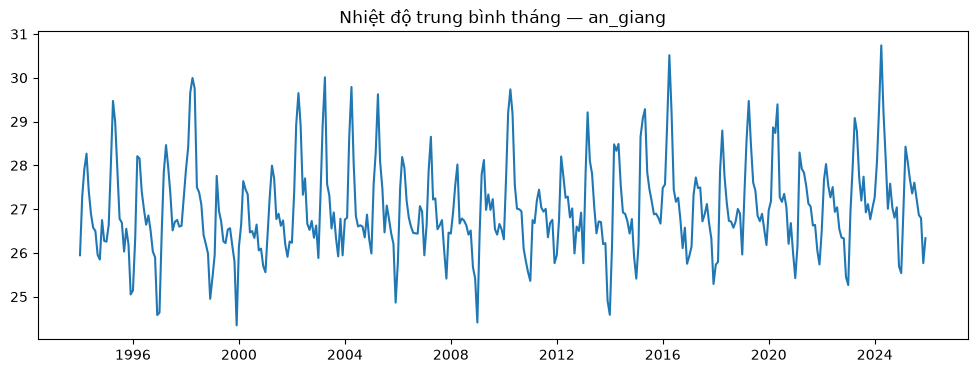

Sanity check pass.


In [7]:
sample_province = climate_panel['province_id'].iloc[0]
series = climate_panel[climate_panel['province_id'] == sample_province].sort_values('month')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(series['month'], series['temp_mean'])
ax.set_title(f'Nhiệt độ trung bình tháng — {sample_province}')
plt.show()

assert climate_panel['temp_mean'].between(5, 40).mean() > 0.95, 'Quá nhiều giá trị nhiệt độ ngoài khoảng hợp lý'
print('Sanity check pass.')

## Lưu ra `data/interim/`

In [8]:
interim_dir = _root / 'data' / 'interim'
interim_dir.mkdir(parents=True, exist_ok=True)
out_path = interim_dir / 'climate_by_province_month.parquet'
climate_panel.to_parquet(out_path, index=False)
print(f'Đã lưu {len(climate_panel)} dòng vào {out_path}')

Đã lưu 13056 dòng vào d:\Cuộc thi\DengueSense\ai-service\data\interim\climate_by_province_month.parquet


**Tiếp theo:** sau khi cả 3 notebook (00, 01, 02) đã lưu xong `data/interim/*.parquet`, chạy từ thư mục `ai-service/`:
```bash
python -m app.data.build_panel
```
`VERSION` tự lên `0.2.0` khi phát hiện đủ cả 3 nguồn — xem `app/data/build_panel.py`.